# 02 Makemore Bigrams

A lecture 2 build log for a character-level bigram language model.

## Scope
- rebuild the count-based bigram baseline from scratch
- evaluate with average negative log-likelihood
- compare the count model against a neural bigram across train-set sizes

## Research Delta
Hold the modeling family fixed at bigrams, and change only the parameterization:

- baseline: add-one smoothed count matrix
- delta: learned neural bigram logits
- controlled variable: amount of training data


In [16]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.makemore_bigram import (
    average_negative_log_likelihood,
    build_vocab,
    count_bigram_matrix,
    evaluate_data_regimes,
    load_words,
    sample_from_prob_matrix,
    split_words,
    train_neural_bigram,
)

DATA_PATH = ROOT / "data" / "names.txt"
SEED = 42
torch.manual_seed(SEED)


In [17]:
words = open(DATA_PATH, 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [18]:
len(words)

32033

In [19]:
min(len(w) for w in words)

2

In [20]:
for w in words[:1]:
    for ch1, ch2 in zip(w, w[1:]):
        print(ch1, ch2)

e m
m m
m a


In [21]:
N = torch.zeros((27,27), dtype = torch.int32)

In [22]:

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

# stoi['<E>'] = 27

In [23]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [26]:
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1
    
        # biagram = (ch1, ch2)
        # b[biagram] = b.get(biagram, 0) + 1
        # print(ch1, ch2)

In [27]:
# sorted(b.items(), key = lambda kv: -kv[1])[:5]

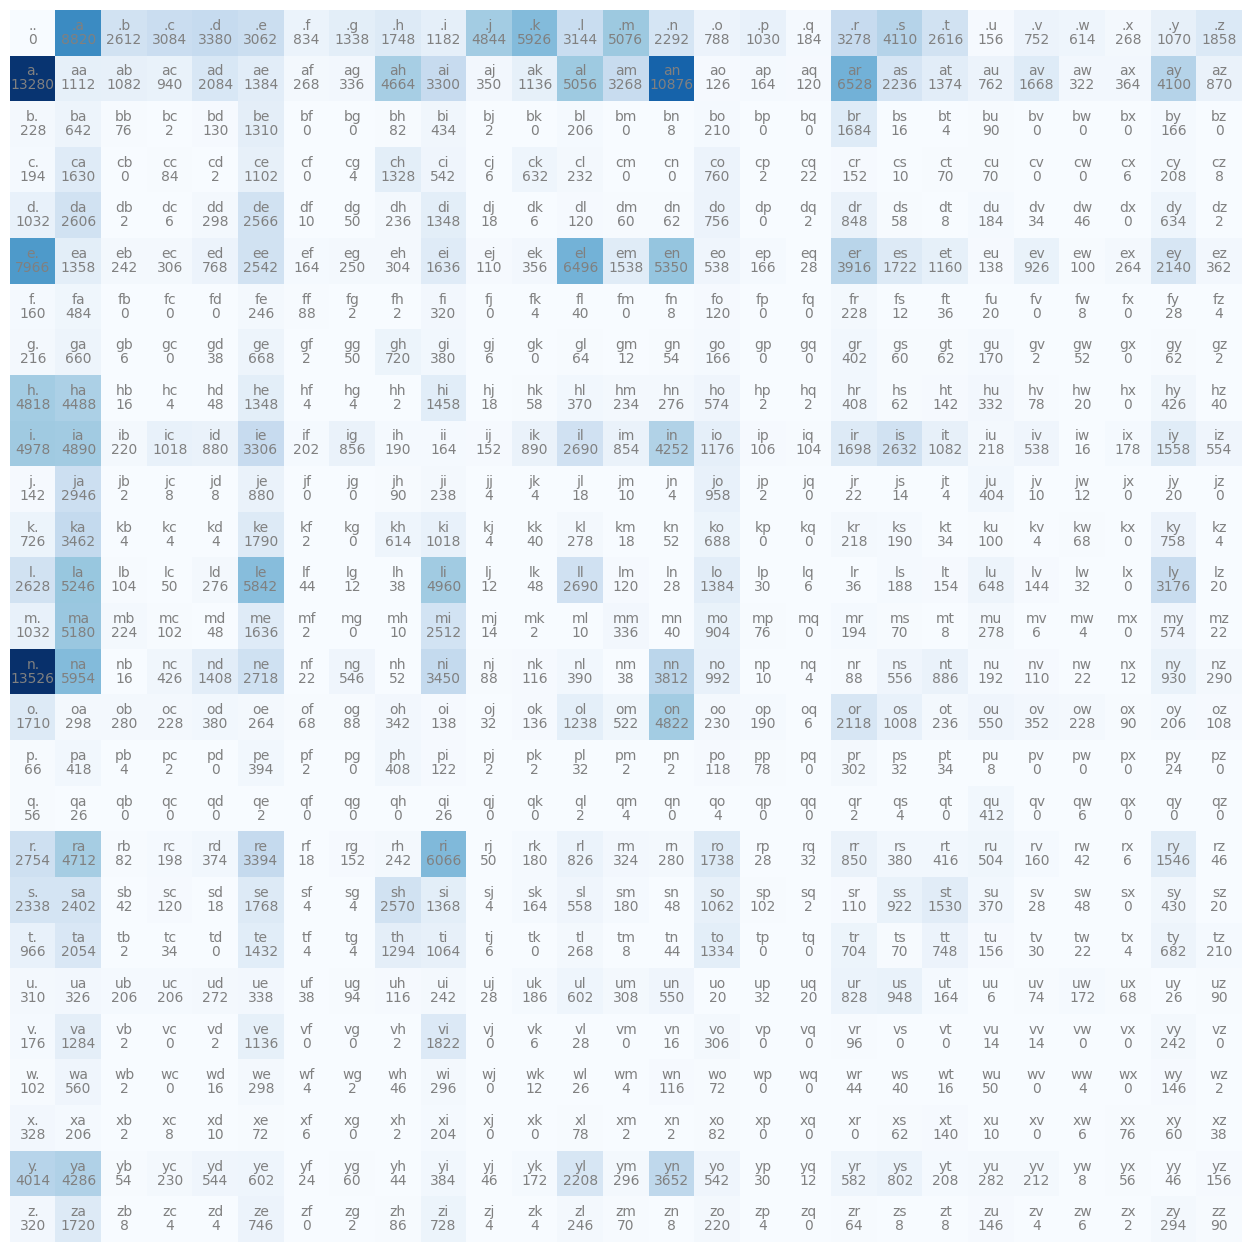

In [28]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [29]:
N[0]

tensor([   0, 8820, 2612, 3084, 3380, 3062,  834, 1338, 1748, 1182, 4844, 5926,
        3144, 5076, 2292,  788, 1030,  184, 3278, 4110, 2616,  156,  752,  614,
         268, 1070, 1858], dtype=torch.int32)

In [30]:
p = N[0].float()
p = p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [31]:
g = torch.Generator().manual_seed(2147483647)
h = torch.rand(3, generator=g)
h = h/h.sum()
h

tensor([0.6064, 0.3033, 0.0903])

In [32]:
torch.multinomial(h, num_samples = 100, replacement = True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [33]:
P = N.float()
P.sum(dim=1)

tensor([64066., 67770.,  5290.,  7064., 10992., 40846.,  1810.,  3854., 15232.,
        35402.,  5800., 10080., 27916., 13284., 36654., 15868.,  2052.,   544.,
        25400., 16212., 11140.,  6270.,  5146.,  1858.,  1394., 19552.,  4796.])

In [34]:
p = N[0].float()
p = p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [35]:
P = (N+1).float()
P = P.sum(dim=0, keepdim=True)
P

tensor([[64093., 67797.,  5317.,  7091., 11019., 40873.,  1837.,  3881., 15259.,
         35429.,  5827., 10107., 27943., 13311., 36681., 15895.,  2079.,   571.,
         25427., 16239., 11167.,  6297.,  5173.,  1885.,  1421., 19579.,  4823.]])

In [36]:
P.shape

torch.Size([1, 27])

In [37]:
P = N.float()
P = P.sum(dim=0, keepdim=False)
P

tensor([64066., 67770.,  5290.,  7064., 10992., 40846.,  1810.,  3854., 15232.,
        35402.,  5800., 10080., 27916., 13284., 36654., 15868.,  2052.,   544.,
        25400., 16212., 11140.,  6270.,  5146.,  1858.,  1394., 19552.,  4796.])

In [38]:
P.shape

torch.Size([27])

In [39]:
P = N.float()
# adding it horizontally, collapsing the columns
P /= P.sum(dim=1, keepdim=True)


In [40]:
# we are divining 27 27 with 27,1 matrix
# 27, 27
# 27, 1
# the 1 dimesnion is copied and steched out

In [41]:

g = torch.Generator().manual_seed(2147483647)
for i in range(50):
    ix = 0
    out = []
    while True:
        # p = N[ix].float()
        # p = p/p.sum()
        p = P[ix]
        ix = torch.multinomial(p, num_samples = 1, replacement = True, generator=g).item()
        out.append(itos[ix])
        # print(itos[ix])
        if ix==0:
            break
    print(''.join(out))
      
            

junide.
janasah.
p.
cony.
a.
nn.
kohin.
tolian.
juee.
ksahnaauranilevias.
dedainrwieta.
ssonielylarte.
faveumerifontume.
phynslenaruani.
core.
yaenon.
ka.
jabdinerimikimaynin.
anaasn.
ssorionsush.
dgossmitan.
il.
le.
pann.
that.
janreli.
isa.
dyn.
rijelumemahaunayaleva.
cararr.
jen.
janarta.
maly.
abely.
a.
i.
lavadoni.
themielyawat.
f.
modam.
tavilitikiesaloeverin.
n.
e.
kalbrenelah.
anen.
ch.
k.
jan.
odridrdenanialilpergha.
tezralelia.


In [42]:
# quality - loss?



In [43]:
log_likelihood = 0.0
n = 0

for w in words:
#for w in ["vallarijq"]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
    # print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

    

log_likelihood=tensor(-559891.7500)
nll=tensor(559891.7500)
2.454094171524048


In [44]:
1/27 # if everything was equally likely it would be 4, if model was completely random it would give 4% 
# the prob in training dataset shoould be as high as one since this is what wee trained on

0.037037037037037035

In [45]:
# max likelhood estimation, statistical modelin - 
# product of all the probabilities in datatset should be as high as possible when training thee model - likelihood
# the product of these numbers will be very tiny - hard to work with
# so we do log likelihood, we take log of proababilites
# for small 0.0478 -3.0408, log iis more negative

In [46]:
# a * b * c
# take log(a * b * c) = log a + log b + log c
# when all the prob is 1, log likelohood = 1
# when all prb is lower log lik - extremely negative

In [47]:
# negative log likelihood is negative is, so when u lower the loss, we do better, then we do avergae 
# job of training is to max liklihood, model parameters - in our case it is what is defined in the taable P - thee probabilites

In [48]:
# we also sommth the model so it is not inf unlikley, since for exaple prob of jq = 0, but we want it to be not inf
# so we add P = (N+1).float()

## Load the dataset

The lecture uses a newline-delimited list of baby names. Keep a held-out split from the start so the experiment has a clean validation metric.


## Training Data

In [49]:
# input xs, output ys
xs, ys = [], []
for w in words[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    print(ch1,ch2)
    xs.append(ix1)
    ys.append(ix2)
print (xs,ys)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
print(xs, ys)
    

. e
e m
m m
m a
a .
[0, 5, 13, 13, 1] [5, 13, 13, 1, 0]
tensor([ 0,  5, 13, 13,  1]) tensor([ 5, 13, 13,  1,  0])


In [50]:
# how do u feed theese in neural netowrk, it is integrer of chars, can't feed ints in neural network, 
# we multiply it by weights - it doesn't make send

# we have one hot encoding that converts it in vector? why ? feed entire array of xs
# num claseess = 27, 

# encoding ints to vectors, careful with datatype, we want it to be floats so cast it to float
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc


tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [51]:
xenc.shape

torch.Size([5, 27])

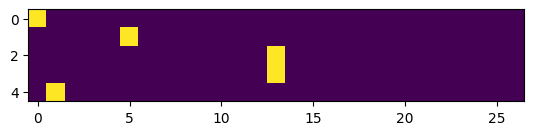

In [52]:
plt.imshow(xenc)

In [53]:
# construct first neuron, wx + b, what should be the weights and neurons, what should be the shape of it?

W = torch.randn(27,27)
W

tensor([[ 1.9269e+00,  1.4873e+00,  9.0072e-01, -2.1055e+00,  6.7842e-01,
         -1.2345e+00, -4.3067e-02, -1.6047e+00, -7.5214e-01,  1.6487e+00,
         -3.9248e-01, -1.4036e+00, -7.2788e-01, -5.5943e-01, -7.6884e-01,
          7.6245e-01,  1.6423e+00, -1.5960e-01, -4.9740e-01,  4.3959e-01,
         -7.5813e-01,  1.0783e+00,  8.0080e-01,  1.6806e+00,  1.2791e+00,
          1.2964e+00,  6.1047e-01],
        [ 1.3347e+00, -2.3162e-01,  4.1759e-02, -2.5158e-01,  8.5986e-01,
         -1.3847e+00, -8.7124e-01, -2.2337e-01,  1.7174e+00,  3.1888e-01,
         -4.2452e-01,  3.0572e-01, -7.7459e-01, -1.5576e+00,  9.9564e-01,
         -8.7979e-01, -6.0114e-01, -1.2742e+00,  2.1228e+00, -1.2347e+00,
         -4.8791e-01, -9.1382e-01, -6.5814e-01,  7.8024e-02,  5.2581e-01,
         -4.8799e-01,  1.1914e+00],
        [-8.1401e-01, -7.3599e-01, -1.4032e+00,  3.6004e-02, -6.3477e-02,
          6.7561e-01, -9.7807e-02,  1.8446e+00, -1.1845e+00,  1.3835e+00,
          1.4451e+00,  8.5641e-01,  2.21

In [54]:
xenc @ W

tensor([[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047,
         -0.7521,  1.6487, -0.3925, -1.4036, -0.7279, -0.5594, -0.7688,  0.7624,
          1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806,
          1.2791,  1.2964,  0.6105],
        [ 0.5760,  1.1415,  0.0186, -1.8058,  0.9254, -0.3753,  1.0331, -0.6867,
          0.6368, -0.9727,  0.9585,  1.6192,  1.4506,  0.2695, -0.2104, -0.7328,
          0.1043,  0.3488,  0.9676, -0.4657,  1.6048, -2.4801, -0.4175, -1.1955,
          0.8123, -1.9006,  0.2286],
        [-0.3303, -0.7939,  0.3752,  0.0879, -1.2415, -0.3203, -0.8444, -0.5513,
          1.9890,  1.9003,  1.6951,  0.0281, -0.1754, -1.7735, -0.7046, -0.3947,
          1.8868, -0.2184,  0.1663,  2.1442,  1.7046,  0.3459,  0.6425, -0.2040,
          0.6854, -0.1397, -1.1808],
        [-0.3303, -0.7939,  0.3752,  0.0879, -1.2415, -0.3203, -0.8444, -0.5513,
          1.9890,  1.9003,  1.6951,  0.0281, -0.1754, -1.7735, -0.7046, -0.3947

In [55]:
# (5, 27) @ (27, 1) -> (5,1)
# (5, 27) @ (27, 27) -> (5,27)

In [56]:
(xenc @ W)[3, 13]
# firing rate of 13th neuron, looking at 34r input, the way it is achieved is by using dot product between ...

tensor(-1.7735)

In [57]:
# neural network sends out logit, those number are not probability, those don't come out of neural net
# to interpret - we get log counts, to get counts we exponentiate it
# e^x - number -ve or ve, -ve - lower than 1, > 0 always gretert than 1 go to infitiy
# we element wise exp it, + ve number, even more + ve
# so now we can interpret it as something counts
# prob are counts normalized

In [58]:
logits = xenc @ W # log-counts
counts = logits.exp() # equivalent N
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.1230, 0.0793, 0.0441, 0.0022, 0.0353, 0.0052, 0.0172, 0.0036, 0.0084,
         0.0932, 0.0121, 0.0044, 0.0087, 0.0102, 0.0083, 0.0384, 0.0926, 0.0153,
         0.0109, 0.0278, 0.0084, 0.0527, 0.0399, 0.0962, 0.0644, 0.0655, 0.0330],
        [0.0396, 0.0698, 0.0227, 0.0037, 0.0562, 0.0153, 0.0626, 0.0112, 0.0421,
         0.0084, 0.0581, 0.1125, 0.0951, 0.0292, 0.0181, 0.0107, 0.0247, 0.0316,
         0.0586, 0.0140, 0.1109, 0.0019, 0.0147, 0.0067, 0.0502, 0.0033, 0.0280],
        [0.0123, 0.0078, 0.0250, 0.0187, 0.0050, 0.0125, 0.0074, 0.0099, 0.1254,
         0.1147, 0.0934, 0.0176, 0.0144, 0.0029, 0.0085, 0.0116, 0.1132, 0.0138,
         0.0203, 0.1464, 0.0943, 0.0242, 0.0326, 0.0140, 0.0340, 0.0149, 0.0053],
        [0.0123, 0.0078, 0.0250, 0.0187, 0.0050, 0.0125, 0.0074, 0.0099, 0.1254,
         0.1147, 0.0934, 0.0176, 0.0144, 0.0029, 0.0085, 0.0116, 0.1132, 0.0138,
         0.0203, 0.1464, 0.0943, 0.0242, 0.0326, 0.0140, 0.0340, 0.0149, 0.0053],
        [0.0934, 0.0195,

In [59]:
probs.shape

torch.Size([5, 27])

In [60]:
probs[0].sum()

tensor(1.0000)

In [61]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [62]:
xs

tensor([ 0,  5, 13, 13,  1])

In [63]:
ys

tensor([ 5, 13, 13,  1,  0])

In [64]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
loss = -probs[torch.arange(5), ys].log().mean()


In [65]:
print(loss.item())

3.7693049907684326


In [66]:
# backward pass
W.grad = None # set to zero the gradient
loss.backward()

In [67]:
W.data += -0.1 * W.grad

In [68]:
# wee have 5 example making up eemma
# 

In [69]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())


--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
       grad_fn=<SelectBackward0>)
label (actual next character): 5
probability assigned by the net to the the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
       grad_fn=<SelectBackward0>)
label (actual next character):

In [70]:
# xs is currenlty integer, of 5 input examples - we will need to convert it to vector
# firsst forward pass - single linear layer, followed by softmax
# for backward - loss is negative log likelihood - we are doing classification
# probs - 5,27, we care about - probs[0,5], probs[1,13], probs[2, 13], probs[3,1], probs[4,0]
# as u see the probs are terrible - very low - (tensor(0.0123, grad_fn=<SelectBackward0>),
 # tensor(0.0181, grad_fn=<SelectBackward0>),
 # tensor(0.0267, grad_fn=<SelectBackward0>),
 # tensor(0.0737, grad_fn=<SelectBackward0>),
 # tensor(0.0150, grad_fn=<SelectBackward0>))
# probs[torch.arange(5), ys] - prob that neural network assign to next char
# loss =  -probs[torch.arange(5), ys].log().mean() - vectorized form of loss 
# set the gradieent to be zero and do loss backwards
# something magical happeen when we call .backward - it fills in gradieent as it knows all dependency,  all the way back to W - parameter of neural net
# W[0.0] += h, will inc the loss mildly, since gradient is +ve? - not sure how?
# update to tensore - W.data += -0.1 * W.grad
# loss should dec after, loss = 

In [71]:
probs.shape

torch.Size([5, 27])

In [72]:
probs[0,5], probs[1,13], probs[2, 13], probs[3,1], probs[4,0]

(tensor(0.0123, grad_fn=<SelectBackward0>),
 tensor(0.0181, grad_fn=<SelectBackward0>),
 tensor(0.0267, grad_fn=<SelectBackward0>),
 tensor(0.0737, grad_fn=<SelectBackward0>),
 tensor(0.0150, grad_fn=<SelectBackward0>))

In [73]:
torch.arange(5)

tensor([0, 1, 2, 3, 4])

In [74]:
probs[torch.arange(5), ys]

tensor([0.0123, 0.0181, 0.0267, 0.0737, 0.0150], grad_fn=<IndexBackward0>)

In [75]:
loss =  -probs[torch.arange(5), ys].log().mean()
loss

tensor(3.7693, grad_fn=<NegBackward0>)

In [76]:
W.grad[0,0]

tensor(0.0121)

## putting it togetger - optimization

In [77]:
# create the dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [78]:
for k in range(100):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad

3.768618583679199
3.3788068294525146
3.161090850830078
3.0271859169006348
2.9344842433929443
2.867231607437134
2.8166542053222656
2.777146577835083
2.745253801345825
2.7188305854797363
2.696505308151245
2.6773719787597656
2.6608052253723145
2.6463515758514404
2.633665084838867
2.622471570968628
2.6125476360321045
2.6037068367004395
2.595794916152954
2.5886807441711426
2.5822560787200928
2.576429843902588
2.5711236000061035
2.566272735595703
2.5618226528167725
2.5577261447906494
2.5539441108703613
2.550442695617676
2.5471930503845215
2.5441696643829346
2.5413522720336914
2.538722038269043
2.536262035369873
2.5339579582214355
2.531797409057617
2.529768228530884
2.527860164642334
2.5260636806488037
2.5243704319000244
2.522773265838623
2.52126407623291
2.519836664199829
2.5184857845306396
2.5172054767608643
2.515990734100342
2.5148372650146484
2.5137407779693604
2.51269793510437
2.511704921722412
2.5107579231262207
2.509855031967163
2.5089924335479736
2.5081686973571777
2.507380247116089
2

## Lecture 2 Exercises

These exercises continue from the last hand-worked training cell and keep the solutions self-contained so they can be rerun independently.

In [79]:
from pathlib import Path
import sys
import pandas as pd
import torch
import torch.nn.functional as F

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.makemore_bigram import (
    build_bigram_dataset,
    build_trigram_dataset,
    build_vocab,
    count_bigram_matrix,
    count_trigram_tensor,
    load_words,
    sample_from_prob_matrix,
    sample_from_trigram_tensor,
    split_words,
)


def bigram_nll_fast(words, probs, vocab):
    xs, ys = build_bigram_dataset(words, vocab)
    return float(-(probs[xs, ys].clamp_min(1e-12).log()).mean())


def trigram_nll_fast(words, probs, vocab):
    x1, x2, ys = build_trigram_dataset(words, vocab)
    return float(-(probs[x1, x2, ys].clamp_min(1e-12).log()).mean())


words = load_words(ROOT / 'data' / 'names.txt')
vocab = build_vocab(words)
splits = split_words(words, seed=2147483647)
train_words = splits['train']
dev_words = splits['val']
test_words = splits['test']

print({'train_words': len(train_words), 'dev_words': len(dev_words), 'test_words': len(test_words), 'vocab_size': vocab.size})

{'train_words': 25626, 'dev_words': 3203, 'test_words': 3204, 'vocab_size': 27}


### E01: Count Trigram vs Count Bigram

Train a trigram language model by conditioning on two characters and compare its loss against the bigram count model.

In [80]:
_, bigram_probs_full = count_bigram_matrix(words, vocab, smoothing=1.0)
_, trigram_probs_full = count_trigram_tensor(words, vocab, smoothing=1.0)

e1_results = pd.DataFrame([
    {'model': 'count bigram', 'full_data_nll': bigram_nll_fast(words, bigram_probs_full, vocab)},
    {'model': 'count trigram', 'full_data_nll': trigram_nll_fast(words, trigram_probs_full, vocab)},
])
e1_results

,model,full_data_nll
0,count bigram,2.454577
1,count trigram,2.212582


### E02: Train / Dev / Test Split

Split the names into `80% / 10% / 10%`, fit both count models on train only, then evaluate on all three splits.

In [81]:
_, bigram_probs_train = count_bigram_matrix(train_words, vocab, smoothing=1.0)
_, trigram_probs_train = count_trigram_tensor(train_words, vocab, smoothing=1.0)

e2_results = pd.DataFrame([
    {
        'split': split_name,
        'bigram_nll': bigram_nll_fast(split_words_, bigram_probs_train, vocab),
        'trigram_nll': trigram_nll_fast(split_words_, trigram_probs_train, vocab),
    }
    for split_name, split_words_ in [
        ('train', train_words),
        ('dev', dev_words),
        ('test', test_words),
    ]
])
e2_results

,split,bigram_nll,trigram_nll
0,train,2.455483,2.215405
1,dev,2.455158,2.246454
2,test,2.451399,2.231170


### E03: Tune Trigram Smoothing on the Dev Set

Sweep smoothing strengths, pick the best finite dev loss, and evaluate that setting once on the test split.

In [82]:
smoothing_grid = [0.0, 1e-3, 3e-3, 1e-2, 3e-2, 5e-2, 8e-2, 1e-1, 1.2e-1, 1.4e-1, 1.6e-1, 1.8e-1, 2e-1, 3e-1, 1.0, 3.0, 10.0]
rows = []
for smoothing in smoothing_grid:
    _, trigram_probs_s = count_trigram_tensor(train_words, vocab, smoothing=smoothing)
    rows.append({
        'smoothing': smoothing,
        'train_nll': trigram_nll_fast(train_words, trigram_probs_s, vocab),
        'dev_nll': trigram_nll_fast(dev_words, trigram_probs_s, vocab),
        'test_nll': trigram_nll_fast(test_words, trigram_probs_s, vocab),
    })

e3_results = pd.DataFrame(rows)
finite_e3 = e3_results[e3_results['dev_nll'].notna()].sort_values('dev_nll').reset_index(drop=True)
best_trigram_smoothing = float(finite_e3.loc[0, 'smoothing'])
_, tuned_trigram_probs = count_trigram_tensor(train_words, vocab, smoothing=best_trigram_smoothing)

print({'best_trigram_smoothing': best_trigram_smoothing,
       'best_dev_nll': float(finite_e3.loc[0, 'dev_nll']),
       'best_test_nll': float(finite_e3.loc[0, 'test_nll'])})
finite_e3

{'best_trigram_smoothing': 0.16, 'best_dev_nll': 2.23230242729187, 'best_test_nll': 2.215836763381958}


,smoothing,train_nll,dev_nll,test_nll
0,0.160,2.189846,2.232302,2.215837
1,0.180,2.190612,2.232334,2.215947
2,0.140,2.189062,2.232353,2.215796
3,0.200,2.191363,2.232429,2.216111
4,0.120,2.188259,2.232513,2.215850
5,0.100,2.187433,2.232830,2.216037
6,0.080,2.186583,2.233378,2.216421
7,0.300,2.194930,2.233473,2.217415
8,0.050,2.185246,2.234998,2.217678
9,0.030,2.184300,2.237278,2.219542


### E04 and E05: Row Indexing and `F.cross_entropy`

Verify that explicit one-hot multiplication can be replaced by indexing rows of `W`, then confirm that `F.cross_entropy` matches the manual loss.

In [83]:
xs_emma, ys_emma = build_bigram_dataset(['emma'], vocab)
g = torch.Generator().manual_seed(2147483647)
W_demo = torch.randn((vocab.size, vocab.size), generator=g)

xenc_emma = F.one_hot(xs_emma, num_classes=vocab.size).float()
logits_one_hot = xenc_emma @ W_demo
logits_index = W_demo[xs_emma]
manual_probs = torch.softmax(logits_one_hot, dim=1)
manual_loss = -manual_probs[torch.arange(xs_emma.numel()), ys_emma].log().mean()
ce_loss = F.cross_entropy(logits_index, ys_emma)

pd.DataFrame([
    {
        'check': 'E04 row indexing matches one-hot matmul',
        'value': float((logits_one_hot - logits_index).abs().max()),
    },
    {
        'check': 'E05 manual NLL',
        'value': float(manual_loss),
    },
    {
        'check': 'E05 F.cross_entropy',
        'value': float(ce_loss),
    },
    {
        'check': 'E05 absolute loss diff',
        'value': float(abs(manual_loss - ce_loss)),
    },
])

,check,value
0,E04 row indexing matches one-hot matmul,0.000000e+00
1,E05 manual NLL,3.769305e+00
2,E05 F.cross_entropy,3.769305e+00
3,E05 absolute loss diff,2.384186e-07


### E06: Meta Exercise

Compare bigram and tuned trigram samples plus a few simple sample statistics.

In [84]:
bigram_samples = sample_from_prob_matrix(bigram_probs_train, vocab, num_samples=20, seed=2147483647)
trigram_samples = sample_from_trigram_tensor(tuned_trigram_probs, vocab, num_samples=20, seed=2147483647)
train_set = set(train_words)

def sample_stats(samples):
    return {
        'avg_len': round(sum(map(len, samples)) / len(samples), 2),
        'seen_in_train': sum(s in train_set for s in samples),
        'unique': len(set(samples)),
        'empty': sum(s == '' for s in samples),
    }

sample_stats_df = pd.DataFrame([
    {'model': 'bigram', **sample_stats(bigram_samples)},
    {'model': 'trigram', **sample_stats(trigram_samples)},
])
print('Bigram samples:', bigram_samples[:10])
print('Trigram samples:', trigram_samples[:10])
sample_stats_df

Bigram samples: ['junide', 'janasah', 'p', 'cony', 'a', 'nn', 'kohin', 'tolian', 'juwe', 'ksahnaauranileviasshedainrwieta']
Trigram samples: ['junide', 'janasid', 'prelay', 'adin', 'kairritoper', 'saree', 'kalania', 'yanileniassib', 'ainrwin', 'lessiyanayla']


,model,avg_len,seen_in_train,unique,empty
0,bigram,8.4,1,20,0
1,trigram,6.8,2,20,0


## Exercise Findings

- `E01`: the count trigram model improves over the count bigram model on the full dataset. The average NLL drops from about `2.455` to about `2.213` because the trigram model gets two characters of context instead of one.
- `E02`: after an `80/10/10` split, the trigram model is still better than the bigram model on train, dev, and test. The train loss is lowest, while dev and test are a bit higher, which is the expected generalization gap.
- `E03`: with no smoothing, the trigram model fits the train set best but breaks on dev/test because unseen contexts make some probabilities undefined. A small positive smoothing value works best; in this sweep the best dev loss is around smoothing `0.16`, giving a test NLL of about `2.216`.
- `E04`: replacing `F.one_hot(xs) @ W` with direct row indexing `W[xs]` gives the same logits. The max difference is `0.0` in the check below.
- `E05`: `F.cross_entropy` matches the manual negative log-likelihood up to numerical precision. It is preferable because it works directly on logits, is more numerically stable, and is shorter to write.
- `E06`: comparing generated samples, the tuned trigram model produces more locally coherent names than the bigram model because it conditions on two characters instead of one.


In [85]:
words = load_words(DATA_PATH)
splits = split_words(words, seed=SEED)
train_words = splits["train"]
val_words = splits["val"]
test_words = splits["test"]
vocab = build_vocab(words)

stats = {
    "total_names": len(words),
    "train": len(train_words),
    "val": len(val_words),
    "test": len(test_words),
    "vocab_size": vocab.size,
}
stats


{'total_names': 32033,
 'train': 25626,
 'val': 3203,
 'test': 3204,
 'vocab_size': 27}

## Count-based bigram baseline

Start with the smallest correct model: a smoothed count table and row-normalized transition probabilities.


In [86]:
count_matrix, count_probs = count_bigram_matrix(train_words, vocab, smoothing=1.0)
count_metrics = {
    "train_nll": average_negative_log_likelihood(train_words, count_probs, vocab),
    "val_nll": average_negative_log_likelihood(val_words, count_probs, vocab),
    "test_nll": average_negative_log_likelihood(test_words, count_probs, vocab),
}
count_samples = sample_from_prob_matrix(count_probs, vocab, num_samples=20, seed=SEED)
count_metrics, count_samples[:10]


({'train_nll': 2.4548368915863676,
  'val_nll': 2.453263940171305,
  'test_nll': 2.4583910867763423},
 ['ya',
  'syahavilin',
  'dleekahmangonya',
  'tryahe',
  'chen',
  'ena',
  'da',
  'amiiae',
  'a',
  'keles'])

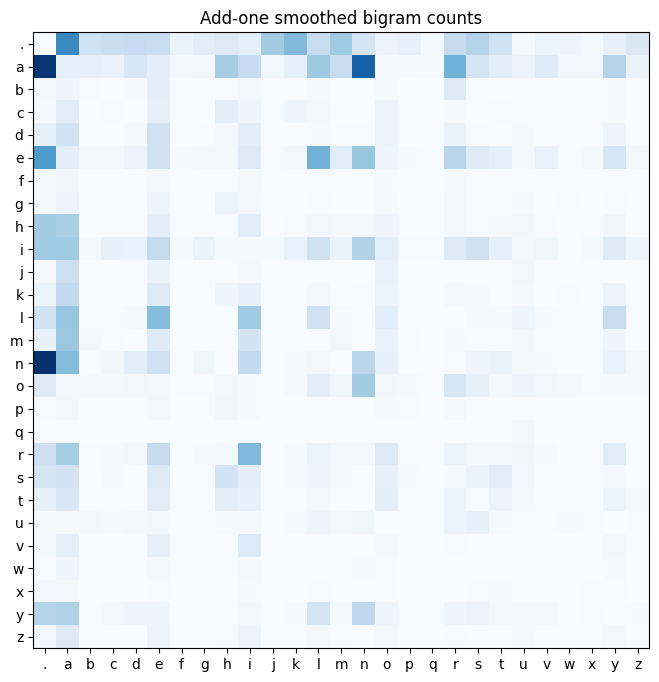

In [87]:
plt.figure(figsize=(8, 8))
plt.imshow(count_matrix, cmap="Blues")
plt.title("Add-one smoothed bigram counts")
plt.xticks(range(vocab.size), [vocab.itos[i] for i in range(vocab.size)])
plt.yticks(range(vocab.size), [vocab.itos[i] for i in range(vocab.size)])
plt.show()


## Neural bigram comparison

This model still predicts the next character from only the current character. The only change is that transition scores are learned with gradient descent instead of filled directly from counts.


In [ ]:
logits, neural_probs, history, neural_metrics = train_neural_bigram(
    train_words,
    val_words,
    vocab,
    num_steps=300,
    learning_rate=30.0,
    weight_decay=1e-2,
    seed=SEED,
)
neural_metrics["test_nll"] = average_negative_log_likelihood(test_words, neural_probs, vocab)
neural_samples = sample_from_prob_matrix(neural_probs, vocab, num_samples=20, seed=SEED)
neural_metrics, neural_samples[:10]


In [ ]:
history_df = pd.DataFrame(history)
history_df.plot(
    x="step",
    y=["train_loss", "val_nll"],
    figsize=(8, 4),
    title="Neural bigram training history",
)
plt.ylabel("loss / NLL")
plt.grid(alpha=0.3)
plt.show()


## Controlled experiment: data regime

Shrink the training set while holding the vocabulary, split logic, and evaluation metric fixed. This isolates how each bigram parameterization behaves as data becomes scarce.


In [ ]:
results = evaluate_data_regimes(
    train_words,
    val_words,
    vocab,
    fractions=(0.01, 0.05, 0.25, 1.0),
    smoothing=1.0,
    num_steps=250,
    learning_rate=30.0,
    weight_decay=1e-2,
    seed=SEED,
)
results_df = pd.DataFrame(results)
results_df


In [ ]:
ax = results_df.plot(
    x="train_examples",
    y=["count_val_nll", "neural_val_nll"],
    marker="o",
    logx=True,
    figsize=(8, 4),
    title="Validation NLL across training-set sizes",
)
ax.set_ylabel("validation NLL")
ax.grid(alpha=0.3)
plt.show()


In [ ]:
# # Building Makemore Bigrams: Lecture 2 Notes

# ## System

# Character-level bigram language model over names.

# Primary reference:

# - Andrej Karpathy, *Neural Networks: Zero to Hero*, lecture 2
# - `makemore_part1_bigrams.ipynb`
# - `karpathy/makemore`

# ## Baseline Build

# Recreate the lecture 2 count-based bigram model with:

# - a shared boundary token `.` for start and stop,
# - a 27 x 27 count matrix,
# - add-one smoothing,
# - row-normalized transition probabilities,
# - ancestral sampling for generated names,
# - average negative log-likelihood on held-out names.

# This is the smallest correct system for the lecture.

# ## Research Delta

# Compare the count-based bigram against a learned neural bigram model across
# different train-set sizes.

# Baseline:

# - add-one smoothed count bigram

# Delta:

# - neural bigram with a learned 27 x 27 logit table

# Controlled variable:

# - amount of training data: `1%`, `5%`, `25%`, `100%`

# Primary metric:

# - validation average negative log-likelihood

# Secondary checks:

# - sample quality,
# - sample diversity,
# - names copied exactly from the training set,
# - length distribution of generated samples.

# ## Why This Delta Works

# It keeps the architecture family intentionally small. Both models are still
# bigram models, so the experiment isolates the difference between:

# - explicit counts with smoothing,
# - learned logits optimized by gradient descent.

# That makes the result easier to explain than jumping immediately to a much
# larger MLP.

# ## Hypothesis

# - At very small data sizes, the count model may be competitive because its
#   inductive bias is strong and smoothing is simple.
# - As data increases, the neural bigram should match or slightly exceed the
#   count model on held-out NLL.
# - Neither model should capture long-range structure well; sample failures
#   should still be visibly local.

# ## Notebook Flow

# 1. Load `data/names.txt`.
# 2. Create train/val/test splits.
# 3. Build the smoothed count bigram.
# 4. Measure NLL and sample names.
# 5. Train the neural bigram on the same split.
# 6. Compare validation NLL across train-set sizes.
# 7. End with one short finding table.

# ## Result Table Template

# | train fraction | train examples | count val NLL | neural val NLL | takeaway |
# | --- | ---: | ---: | ---: | --- |
# | 1% |  |  |  |  |
# | 5% |  |  |  |  |
# | 25% |  |  |  |  |
# | 100% |  |  |  |  |


## Findings

Capture the result in one compact table:

| train fraction | count val NLL | neural val NLL | takeaway |
| --- | ---: | ---: | --- |
| 1% |  |  |  |
| 5% |  |  |  |
| 25% |  |  |  |
| 100% |  |  |  |
